# Ejercicio - Penguins dataset

Un dataset como el de Iris, pero de pingüinos. Es conocido por ser una evolución estadísticamente más interesante. Para más información, leer la [documentación oficial](https://allisonhorst.github.io/palmerpenguins/)

## Dataset


In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


<br>

## Análisis exploratorio



In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Valores nulos

En este caso por simplicidad al ser pocos los vamos a eliminar

In [ ]:
print(df.isnull().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [ ]:
df = df.dropna()

### Duplicados

In [ ]:
df = df.drop_duplicates()

### Outliers

---

## Modelo de Machine Learning

### Train test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

<br>

### Preprocesamiento

Según la naturaleza de cada variable se podría hacer un tipo de preprocesamiento u otro pero de manera general algo que funciona de manera general es lo siguiente:

* Variables numéricas → escalado

* Variables categóricas → one-hot encoding

**Variables categórica island**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

island_encoder = OneHotEncoder(sparse_output=False).fit(X_train[["island"]])
X_train[island_encoder.get_feature_names_out()] = island_encoder.transform(X_train[["island"]])
X_train=X_train.drop("island", axis=1)
X_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
243,46.3,15.8,215.0,5050.0,MALE,1.0,0.0,0.0
196,50.9,17.9,196.0,3675.0,FEMALE,0.0,1.0,0.0
275,45.0,15.4,220.0,5050.0,MALE,1.0,0.0,0.0
255,48.4,16.3,220.0,5400.0,MALE,1.0,0.0,0.0
164,47.0,17.3,185.0,3700.0,FEMALE,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
332,43.5,15.2,213.0,4650.0,FEMALE,1.0,0.0,0.0
198,50.1,17.9,190.0,3400.0,FEMALE,0.0,1.0,0.0
123,41.4,18.5,202.0,3875.0,MALE,0.0,0.0,1.0
53,42.0,19.5,200.0,4050.0,MALE,1.0,0.0,0.0


In [ ]:
X_test[island_encoder.get_feature_names_out()] = island_encoder.transform(X_test[["island"]])
X_test=X_test.drop("island", axis=1)
X_test

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
62,37.6,17.0,185.0,3600.0,FEMALE,1.0,0.0,0.0
60,35.7,16.9,185.0,3150.0,FEMALE,1.0,0.0,0.0
283,54.3,15.7,231.0,5650.0,MALE,1.0,0.0,0.0
107,38.2,20.0,190.0,3900.0,MALE,1.0,0.0,0.0
65,41.6,18.0,192.0,3950.0,MALE,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
122,40.2,17.0,176.0,3450.0,FEMALE,0.0,0.0,1.0
298,45.2,13.8,215.0,4750.0,FEMALE,1.0,0.0,0.0
22,35.9,19.2,189.0,3800.0,FEMALE,1.0,0.0,0.0
151,41.5,18.5,201.0,4000.0,MALE,0.0,1.0,0.0


**Variables categoricas - sex**

In [ ]:
from sklearn.preprocessing import LabelBinarizer

sex_encoder = LabelBinarizer().fit(X_train[["sex"]])
X_train["sex"] = sex_encoder.transform(X_train[["sex"]])
X_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
243,46.3,15.8,215.0,5050.0,1,1.0,0.0,0.0
196,50.9,17.9,196.0,3675.0,0,0.0,1.0,0.0
275,45.0,15.4,220.0,5050.0,1,1.0,0.0,0.0
255,48.4,16.3,220.0,5400.0,1,1.0,0.0,0.0
164,47.0,17.3,185.0,3700.0,0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
332,43.5,15.2,213.0,4650.0,0,1.0,0.0,0.0
198,50.1,17.9,190.0,3400.0,0,0.0,1.0,0.0
123,41.4,18.5,202.0,3875.0,1,0.0,0.0,1.0
53,42.0,19.5,200.0,4050.0,1,1.0,0.0,0.0


In [ ]:
X_test["sex"] = sex_encoder.transform(X_test[["sex"]])
X_test

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
62,37.6,17.0,185.0,3600.0,0,1.0,0.0,0.0
60,35.7,16.9,185.0,3150.0,0,1.0,0.0,0.0
283,54.3,15.7,231.0,5650.0,1,1.0,0.0,0.0
107,38.2,20.0,190.0,3900.0,1,1.0,0.0,0.0
65,41.6,18.0,192.0,3950.0,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
122,40.2,17.0,176.0,3450.0,0,0.0,0.0,1.0
298,45.2,13.8,215.0,4750.0,0,1.0,0.0,0.0
22,35.9,19.2,189.0,3800.0,0,1.0,0.0,0.0
151,41.5,18.5,201.0,4000.0,1,0.0,1.0,0.0


**Variables numéricas**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
243,0.336503,-0.662106,0.960846,1.005596,1,1.0,0.0,0.0
196,1.195380,0.379439,-0.423057,-0.729908,0,0.0,1.0,0.0
275,0.093777,-0.860496,1.325031,1.005596,1,1.0,0.0,0.0
255,0.728599,-0.414119,1.325031,1.447360,1,1.0,0.0,0.0
164,0.467202,0.081854,-1.224264,-0.698353,0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
332,-0.186291,-0.959691,0.815172,0.500722,0,1.0,0.0,0.0
198,1.046010,0.379439,-0.860079,-1.077009,0,0.0,1.0,0.0
123,-0.578387,0.677023,0.013965,-0.477471,1,0.0,0.0,1.0
53,-0.466360,1.172997,-0.131709,-0.256589,1,1.0,0.0,0.0


In [ ]:
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
X_test

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
62,-1.287894,-0.066938,-1.224264,-0.824572,0,1.0,0.0,0.0
60,-1.642647,-0.116535,-1.224264,-1.392555,0,1.0,0.0,0.0
283,1.830202,-0.711704,2.126238,1.762907,1,1.0,0.0,0.0
107,-1.175866,1.420984,-0.860079,-0.445917,1,1.0,0.0,0.0
65,-0.541044,0.429036,-0.714405,-0.382807,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
122,-0.802442,-0.066938,-1.879797,-1.013900,0,0.0,0.0,1.0
298,0.131120,-1.654054,0.960846,0.626940,0,1.0,0.0,0.0
22,-1.605305,1.024204,-0.932916,-0.572135,0,1.0,0.0,0.0
151,-0.559716,0.677023,-0.058872,-0.319698,1,0.0,1.0,0.0


**Target**

In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder().fit(y_train)
y_train = pd.Series(target_encoder.transform(y_train),name='species')
y_train

,species
0,2
1,1
2,2
3,2
4,1
...,...
261,2
262,1
263,0
264,0


In [ ]:
y_test = pd.Series(target_encoder.transform(y_test),name='species')
y_test

,species
0,0
1,0
2,2
3,0
4,0
...,...
62,0
63,2
64,0
65,0


<br>

## Machine Learning

## Entrenamiento

In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "Clasificador Gaussiano": GaussianNB(),
    "Regresión Logística": LogisticRegression(),
    "Clasificador RandomForest": RandomForestClassifier()
}

best_model = None
best_accuracy = 0
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{model_name} accuracy: {round(accuracy,4)}")

    if accuracy >= best_accuracy:
        best_accuracy = accuracy
        best_model = model_name

print()
print(f"El mejor modelo es {best_model} con una precisión de {best_accuracy}")

SVC accuracy: 0.9851
KNN accuracy: 0.9851
Clasificador Gaussiano accuracy: 0.6269
Regresión Logística accuracy: 0.9851
Clasificador RandomForest accuracy: 0.9851

El mejor modelo es Clasificador RandomForest con una precisión de 0.9850746268656716


<br>

### Evaluación

In [ ]:
from sklearn.metrics import classification_report

y_pred = models[best_model].predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        39
           1       1.00      0.90      0.95        10
           2       1.00      1.00      1.00        18

    accuracy                           0.99        67
   macro avg       0.99      0.97      0.98        67
weighted avg       0.99      0.99      0.98        67



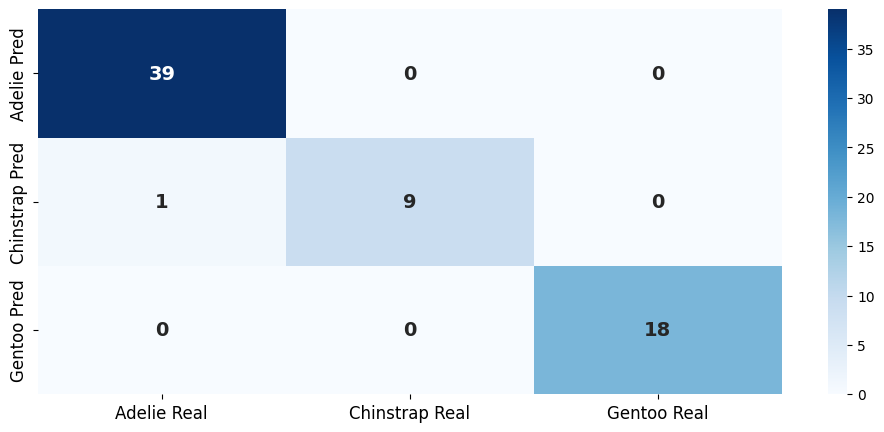

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,5)

# Matriz de confusión
cm = confusion_matrix(
    y_test,
    y_pred,
)

# Grafica
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # annot_kws ajusta el tamaño de los números dentro de las celdas
    annot_kws={"size": 14, "weight": "bold"},
    xticklabels=[f"{c} Real" for c in target_encoder.classes_],
    yticklabels=[f"{c} Pred" for c in target_encoder.classes_]
)

# Ajustar el tamaño de los textos en los ejes (X e Y)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=90)

plt.show()